# 01 - Baseline: 6 modeli na czystych obrazach ImageNet-1k

**Praca magisterska:** *„Analiza wpływu zakłóceń i perturbacji obrazów na stabilność reprezentacji generowanych przez głębokie sieci neuronowe, z uwzględnieniem klas obiektów"*

---

Notebook wyznacza pomiary bazowe dla wszystkich sześciu modeli na zbiorze walidacyjnym bez jakichkolwiek zakłóceń. Wyniki stanowią punkt odniesienia dla analizy w notebooku 04.

Ewaluowane modele:

| Model | Rodzina | Parametry | Wagi |
|---|---|---|---|
| ResNet-50  | CNN | 25.6 M | IMAGENET1K_V2 |
| ResNet-101 | CNN | 44.5 M | IMAGENET1K_V2 |
| ResNet-152 | CNN | 60.2 M | IMAGENET1K_V2 |
| ViT-B/32   | ViT | 88.2 M | IMAGENET1K_V1 |
| ViT-B/16   | ViT | 86.6 M | IMAGENET1K_V1 |
| ViT-L/16   | ViT | 307 M  | IMAGENET1K_V1 |

Wszystkie wagi pochodzą z `torchvision`, co gwarantuje identyczny protokół preprocessingu
i eliminuje efekt różnych pipeline'ów treningowych jako zmienną zakłócającą.
Strona CNN różnicuje wyłącznie głębokość sieci; strona ViT - rozmiar patcha (B/32 vs B/16)
oraz skalę modelu (B vs L).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q datasets

In [ ]:
import os, json, random
import numpy as np
import pandas as pd
import json
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset

random.seed(42); np.random.seed(42); torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU:    {torch.cuda.get_device_name(0)}')
    print(f'VRAM:   {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

from torchvision import models
from datasets import load_dataset, DownloadConfig, VerificationMode
import gc
from huggingface_hub import login

Device: cuda
GPU:    NVIDIA A100-SXM4-40GB
VRAM:   42.4 GB


In [ ]:
# ── ścieżki ───────────────────────────────────────────────────────────────────
ROOT         = '/content/drive/MyDrive/mgr_266484'
DATA_DIR     = f'{ROOT}/data'
BASELINE_DIR = f'{ROOT}/baseline'
RESULTS_DIR  = f'{ROOT}/results'
FIGURES_DIR  = f'{ROOT}/figures'

# ── modele ────────────────────────────────────────────────────────────────────
MODELS = {
    'resnet50':  lambda: models.resnet50 (weights=models.ResNet50_Weights.IMAGENET1K_V2),
    'resnet101': lambda: models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2),
    'resnet152': lambda: models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2),
    'vit_b_32':  lambda: models.vit_b_32 (weights=models.ViT_B_32_Weights.IMAGENET1K_V1),
    'vit_b_16':  lambda: models.vit_b_16 (weights=models.ViT_B_16_Weights.IMAGENET1K_V1),
    'vit_l_16':  lambda: models.vit_l_16 (weights=models.ViT_L_16_Weights.IMAGENET1K_V1),
}

BATCH_SIZES = {
    'resnet50': 256, 'resnet101': 128, 'resnet152': 128,
    'vit_b_32': 128, 'vit_b_16':   64, 'vit_l_16':   32,
}

# ── zakłócenia ────────────────────────────────────────────────────────────────
CORRUPTIONS = {
    'noise':   ['gaussian_noise', 'shot_noise', 'impulse_noise'],
    'blur':    ['defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur'],
    'weather': ['snow', 'frost', 'fog', 'brightness'],
    'digital': ['contrast', 'elastic_transform', 'pixelate', 'jpeg_compression'],
}
SEVERITIES        = [1, 2, 3, 4, 5]
ALL_CORRUPTIONS   = [c for lst in CORRUPTIONS.values() for c in lst]
CORRUPTION_TO_CAT = {c: cat for cat, lst in CORRUPTIONS.items() for c in lst}

SEED = 42

In [ ]:
label_map      = pd.read_csv(f'{DATA_DIR}/label_map.csv')
idx_to_wnid    = dict(zip(label_map['imagenet1k_label'], label_map['wnid']))
inet1k_to_name = {}
with open(f'{DATA_DIR}/imagenet_class_index.json') as f:
    for k, v in json.load(f).items():
        inet1k_to_name[int(k)] = v[1]

## 1. Zbiór i pipeline preprocessingu

Stosowany jest standardowy pipeline ewaluacyjny ImageNet,
gdzie `μ = [0.485, 0.456, 0.406]`, `σ = [0.229, 0.224, 0.225]` to
statystyki pełnego zbioru ImageNet-1k.


In [ ]:
os.environ['HF_DATASETS_CACHE'] = '/content/drive/MyDrive/mgr_266484/hf_cache'

ds_val = load_dataset(
    'ILSVRC/imagenet-1k',
    split='validation',
    data_files={'validation': 'data/validation-*'},
    verification_mode=VerificationMode.NO_CHECKS)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class ImageNetValDataset(Dataset):
    def __init__(self, hf_ds, transform):
        self.ds = hf_ds
        self.transform = transform

    def __len__(self): return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        lbl  = int(item['label'])
        img  = item['image'].convert('RGB')
        return self.transform(img), lbl, idx_to_wnid[lbl], f'inet1k_val_{idx:06d}'

dataset = ImageNetValDataset(ds_val, eval_tf)
print(f'Dataset: {len(dataset):,} obrazów, 1000 klas')

data/validation-00000-of-00014.parquet:   0%|          | 0.00/480M [00:00<?, ?B/s]

data/validation-00001-of-00014.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/validation-00002-of-00014.parquet:   0%|          | 0.00/471M [00:00<?, ?B/s]

data/validation-00003-of-00014.parquet:   0%|          | 0.00/478M [00:00<?, ?B/s]

data/validation-00004-of-00014.parquet:   0%|          | 0.00/478M [00:00<?, ?B/s]

...

data/validation-00011-of-00014.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/validation-00012-of-00014.parquet:   0%|          | 0.00/493M [00:00<?, ?B/s]

data/validation-00013-of-00014.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset: 50,000 obrazów, 1000 klas


## 2. Funkcja ewaluacji

Dla każdego obrazu zapisywane są:
- `filename` - deterministyczny identyfikator (klucz złączeniowy z wynikami notebooka 03),
- `wnid`, `true_idx` - identyfikatory prawdziwej klasy,
- `top1_correct`, `top5_correct` - poprawność predykcji (0/1),
- `true_class_prob` - prawdopodobieństwo softmax przyznane prawdziwej klasie,
- `pred_top1`, `pred_top1_prob` - predykcja top-1 i jej pewność,
- `top5_idx` - pełna piątka top-5.

Identyczna struktura kolumn jest stosowana w notebooku 03, co umożliwia
bezpośrednie złączenie wyników na czystych i zakłóconych obrazach.


In [ ]:
@torch.no_grad()
def evaluate_clean(model, model_name):
    loader = DataLoader(dataset, batch_size=BATCH_SIZES[model_name],
                        shuffle=False, num_workers=4, pin_memory=True)
    records = []
    for imgs, labels, wnids, fnames in tqdm(loader, desc=model_name):
        imgs  = imgs.to(DEVICE, non_blocking=True)
        probs = torch.softmax(model(imgs), dim=1)
        top5_p, top5_i = probs.topk(5, dim=1)
        for j in range(len(imgs)):
            lbl = int(labels[j])
            t5  = top5_i[j].cpu().tolist()
            records.append({
                'filename':        fnames[j],
                'wnid':            wnids[j],
                'true_idx':        lbl,
                'pred_top1':       t5[0],
                'top1_correct':    int(t5[0] == lbl),
                'top5_correct':    int(lbl in t5),
                'true_class_prob': float(probs[j, lbl].cpu()),
                'pred_top1_prob':  float(top5_p[j, 0].cpu()),
                'top5_idx':        ','.join(map(str, t5)),
            })
    return pd.DataFrame(records)

## 3. Uruchomienie ewaluacji

In [ ]:
summary_rows = []
for model_name, model_fn in MODELS.items():
    out_path = f'{BASELINE_DIR}/{model_name}_baseline.csv'

    if os.path.exists(out_path):
        print(f'{model_name}: plik już istnieje, wczytuję.')
        df = pd.read_csv(out_path)
    else:
        model = model_fn().eval().to(DEVICE)
        n_params = sum(p.numel() for p in model.parameters())
        print(f'{model_name}  ({n_params/1e6:.1f} M parametrów)')
        df = evaluate_clean(model, model_name)
        df.to_csv(out_path, index=False)
        del model; gc.collect(); torch.cuda.empty_cache()

    top1 = df['top1_correct'].mean() * 100
    top5 = df['top5_correct'].mean() * 100
    summary_rows.append({'model': model_name, 'top1_acc': round(top1,2), 'top5_acc': round(top5,2)})
    print(f'  top-1 = {top1:.2f}%   top-5 = {top5:.2f}%')

summary = pd.DataFrame(summary_rows)
summary.to_csv(f'{BASELINE_DIR}/baseline_summary.csv', index=False)
print()
print(summary.to_string(index=False))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


resnet50  (25.6 M parametrów)


resnet50:   0%|          | 0/196 [00:00<?, ?it/s]

  top-1 = 80.34%   top-5 = 95.13%
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


...

  top-1 = 81.06%   top-5 = 95.32%
Downloading: "https://download.pytorch.org/models/vit_l_16-852ce7e3.pth" to /root/.cache/torch/hub/checkpoints/vit_l_16-852ce7e3.pth


100%|██████████| 1.13G/1.13G [00:05<00:00, 240MB/s]


vit_l_16  (304.3 M parametrów)


vit_l_16:   0%|          | 0/1563 [00:00<?, ?it/s]

  top-1 = 79.68%   top-5 = 94.54%

    model  top1_acc  top5_acc
 resnet50     80.34     95.13
resnet101     81.67     95.66
resnet152     82.34     95.93
 vit_b_32     75.90     92.47
 vit_b_16     81.06     95.32
 vit_l_16     79.68     94.54


## 4. Wizualizacja

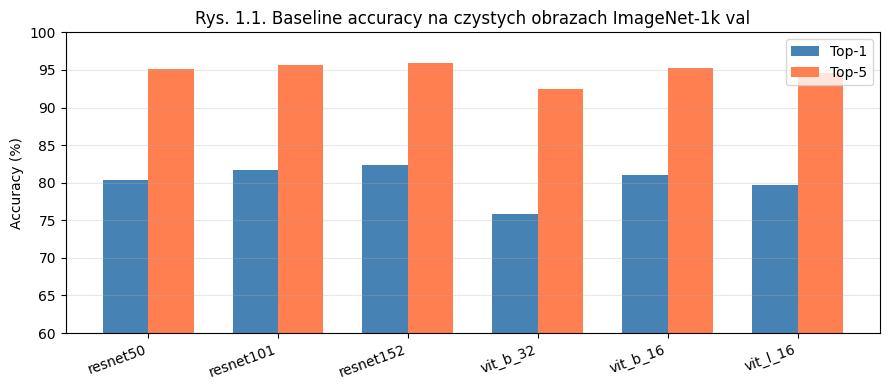

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w/2, summary['top1_acc'], width=w, label='Top-1', color='steelblue')
ax.bar(x + w/2, summary['top5_acc'], width=w, label='Top-5', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(summary['model'], rotation=20, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(60, 100)
ax.set_title('Baseline accuracy na czystych obrazach ImageNet-1k val')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_baseline_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()